In [21]:
import os
import shutil

dst = 'speech_commands_v0.02'
os.makedirs(dst, exist_ok=True)
for name in os.listdir('.'):
    if name in (dst, 'speech_command_cnn_rl_vscode.ipynb', 'speech_commands_v0.02.tar.gz'):
        continue
    if name.startswith('.'):
        continue
    shutil.move(name, os.path.join(dst, name))
print('Moved files into', dst)

Moved files into speech_commands_v0.02


In [22]:
import urllib.request
import tarfile

url = 'http://download.tensorflow.org/data/speech_commands_v0.02.tar.gz'
archive = 'speech_commands_v0.02.tar.gz'
print('Downloading', url)
urllib.request.urlretrieve(url, archive)
print('Download complete — extracting...')
with tarfile.open(archive, 'r:gz') as tar:
    tar.extractall()
print('Extraction complete')

Download complete — extracting...
Extraction complete


In [23]:
%pip install tqdm scikit-learn -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
%pip install "tensorflow" -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
%pip install numpy pandas matplotlib scipy librosa -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
%pip install seaborn -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Speech Command Recognition — CNN + RL Threshold Tuning
**Dataset**: Google Speech Commands V2 (Kaggle)  
**Model**: Mel Spectrogram → CNN (Keras/TensorFlow)  
**RL Agent**: Q-learning threshold tuner (minimize false rejects)  
**Metrics**: Accuracy, Macro-F1, Expected Cost

## 1. Imports & Configuration

In [27]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tqdm import tqdm

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.21.0
GPU available: False


In [28]:
# ── Paths ────────────────────────────────────────────────────────────
# Update DATA_DIR to wherever you extracted the dataset on your machine
# e.g. Windows: r'C:/Users/you/datasets/speech_commands_v0.02'
#      Mac/Linux: '/home/you/datasets/speech_commands_v0.02'
DATA_DIR = './speech_commands_v0.02'

# ── Audio config ──────────────────────────────────────────────────────
SAMPLE_RATE   = 16000   # all clips are 16kHz
CLIP_DURATION = 1.0     # seconds — pad/trim all clips to exactly 1s
N_SAMPLES     = int(SAMPLE_RATE * CLIP_DURATION)

# ── Mel Spectrogram config ───────────────────────────────────────────
N_MELS     = 64
HOP_LENGTH = 512
N_FFT      = 1024
FMAX       = 8000

# ── CNN training config ──────────────────────────────────────────────
BATCH_SIZE = 64
EPOCHS     = 30
LR         = 1e-3

# ── RL config ────────────────────────────────────────────────────────
# Cost matrix (asymmetric — false rejects cost more)
COST_FALSE_REJECT = 2.0   # penalty when the model misses a real command
COST_FALSE_ACCEPT = 1.0   # penalty when model accepts noise/wrong command

# Labels to keep (35 commands + _silence_ + _unknown_)
COMMANDS = [
    'yes', 'no', 'up', 'down', 'left', 'right',
    'on', 'off', 'stop', 'go',
    'zero', 'one', 'two', 'three', 'four',
    'five', 'six', 'seven', 'eight', 'nine',
    'bed', 'bird', 'cat', 'dog', 'happy',
    'house', 'marvin', 'sheila', 'tree', 'wow',
    'backward', 'forward', 'follow', 'learn', 'visual'
]

print(f'Commands to classify: {len(COMMANDS)}')

Commands to classify: 35


## 2. Dataset Loading

In [29]:
def load_file_list(data_dir, commands):
    """
    Walk the dataset directory and collect (filepath, label) pairs.
    Uses the official validation_list.txt and testing_list.txt splits.
    """
    val_files  = set(open(os.path.join(data_dir, 'validation_list.txt')).read().splitlines())
    test_files = set(open(os.path.join(data_dir, 'testing_list.txt')).read().splitlines())

    records = []
    for cmd in commands:
        cmd_dir = os.path.join(data_dir, cmd)
        if not os.path.isdir(cmd_dir):
            continue
        for fname in os.listdir(cmd_dir):
            if not fname.endswith('.wav'):
                continue
            rel = f'{cmd}/{fname}'
            split = 'val' if rel in val_files else 'test' if rel in test_files else 'train'
            records.append({
                'path':  os.path.join(cmd_dir, fname),
                'label': cmd,
                'split': split
            })

    df = pd.DataFrame(records)
    print(df['split'].value_counts())
    return df

df = load_file_list(DATA_DIR, COMMANDS)
df.head()

split
train    84843
test     11005
val       9981
Name: count, dtype: int64


,path,label,split
0,./speech_commands_v0.02\yes\004ae714_nohash_0.wav,yes,train
1,./speech_commands_v0.02\yes\004ae714_nohash_1.wav,yes,train
2,./speech_commands_v0.02\yes\00970ce1_nohash_0.wav,yes,train
3,./speech_commands_v0.02\yes\00f0204f_nohash_0.wav,yes,train
4,./speech_commands_v0.02\yes\00f0204f_nohash_1.wav,yes,train


In [30]:
# Encode labels to integers
le = LabelEncoder()
df['label_id'] = le.fit_transform(df['label'])
NUM_CLASSES = len(le.classes_)
print(f'Classes ({NUM_CLASSES}):', le.classes_)

Classes (35): ['backward' 'bed' 'bird' 'cat' 'dog' 'down' 'eight' 'five' 'follow'
 'forward' 'four' 'go' 'happy' 'house' 'learn' 'left' 'marvin' 'nine' 'no'
 'off' 'on' 'one' 'right' 'seven' 'sheila' 'six' 'stop' 'three' 'tree'
 'two' 'up' 'visual' 'wow' 'yes' 'zero']


## 3. Feature Extraction — Mel Spectrograms

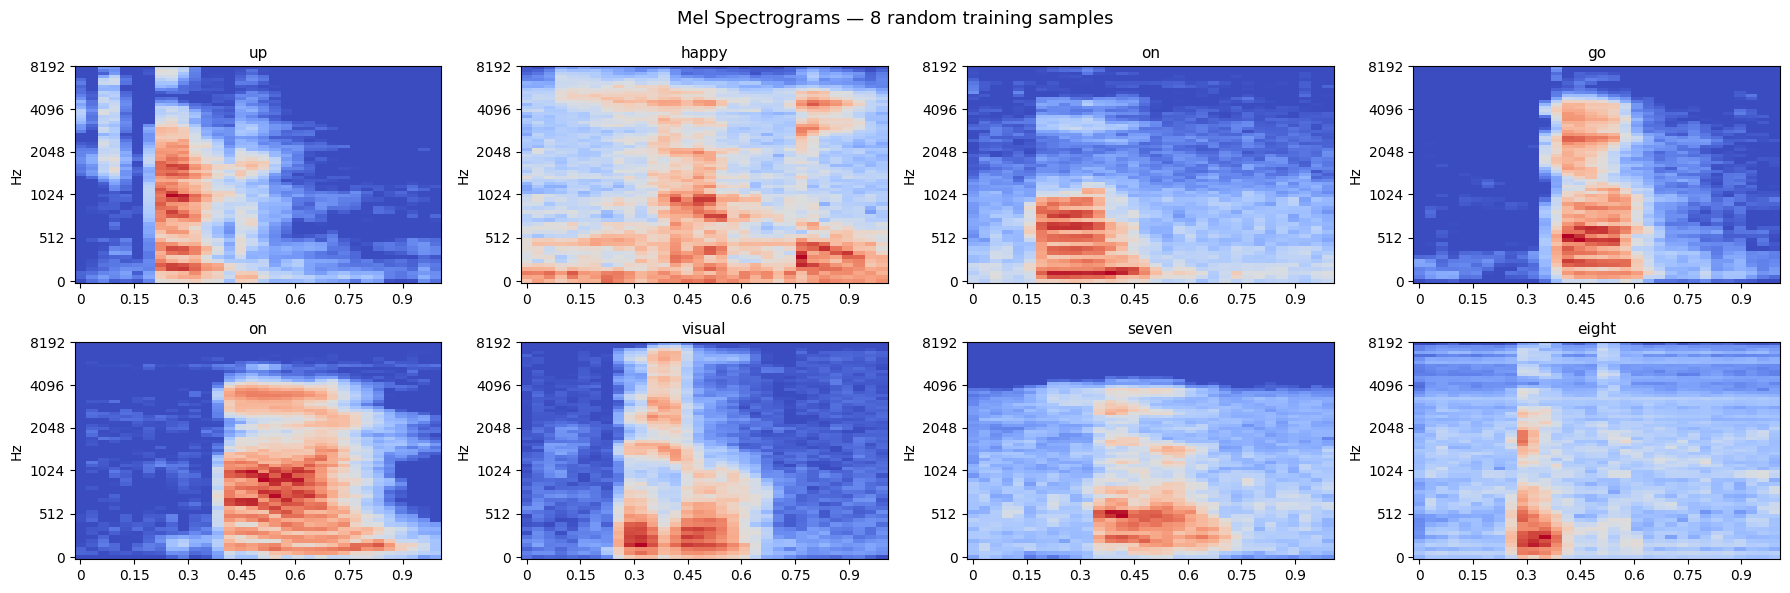

In [31]:
def load_wav(path, sr=SAMPLE_RATE, n_samples=N_SAMPLES):
    """Load a .wav file, resample, pad/trim to exactly n_samples."""
    y, _ = librosa.load(path, sr=sr, mono=True)
    if len(y) < n_samples:
        y = np.pad(y, (0, n_samples - len(y)))
    else:
        y = y[:n_samples]
    return y


def wav_to_melspec(y, sr=SAMPLE_RATE, n_mels=N_MELS,
                   n_fft=N_FFT, hop_length=HOP_LENGTH, fmax=FMAX):
    """
    Convert a waveform to a log-Mel spectrogram.
    Output shape: (n_mels, time_frames, 1)  — channel-last for Keras Conv2D
    """
    S = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=n_mels,
        n_fft=n_fft, hop_length=hop_length, fmax=fmax
    )
    S_db = librosa.power_to_db(S, ref=np.max)  # log scale
    S_db = (S_db - S_db.mean()) / (S_db.std() + 1e-8)  # normalize
    return S_db[..., np.newaxis]  # add channel dim


def extract_features(df_split):
    """Extract mel-spectrograms for an entire split."""
    X, y = [], []
    for _, row in tqdm(df_split.iterrows(), total=len(df_split)):
        wav = load_wav(row['path'])
        spec = wav_to_melspec(wav)
        X.append(spec)
        y.append(row['label_id'])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)


# Visualise a few examples
fig, axes = plt.subplots(2, 4, figsize=(18, 6))
for ax, (_, row) in zip(axes.flat, df[df['split']=='train'].sample(8, random_state=SEED).iterrows()):
    wav = load_wav(row['path'])
    S = wav_to_melspec(wav)[..., 0]
    librosa.display.specshow(S, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                             x_axis='time', y_axis='mel', ax=ax, fmax=FMAX)
    ax.set_title(row['label'], fontsize=11)
    ax.set_xlabel('')
plt.suptitle('Mel Spectrograms — 8 random training samples', fontsize=13)
plt.tight_layout()
plt.show()

In [32]:
# Extract all splits  (this takes a few minutes — ~105k files total)
print('Extracting training features...')
X_train, y_train = extract_features(df[df['split']=='train'])

print('Extracting validation features...')
X_val, y_val = extract_features(df[df['split']=='val'])

print('Extracting test features...')
X_test, y_test = extract_features(df[df['split']=='test'])

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
INPUT_SHAPE = X_train.shape[1:]  # (n_mels, time_frames, 1)

Extracting training features...


100%|██████████| 84843/84843 [02:20<00:00, 602.75it/s]


Extracting validation features...


100%|██████████| 9981/9981 [00:16<00:00, 610.30it/s]


Extracting test features...


100%|██████████| 11005/11005 [00:18<00:00, 604.45it/s]

Train: (84843, 64, 32, 1), Val: (9981, 64, 32, 1), Test: (11005, 64, 32, 1)


## 4. CNN Model

In [33]:
def build_cnn(input_shape, num_classes):
    """
    Compact CNN for mel-spectrogram classification.
    Architecture: 4x [Conv2D → BN → ReLU → MaxPool] → GlobalAvgPool → Dense
    """
    inputs = keras.Input(shape=input_shape, name='mel_spectrogram')

    x = inputs
    for filters in [32, 64, 128, 128]:
        x = layers.Conv2D(filters, (3, 3), padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D((2, 2))(x)
        x = layers.Dropout(0.25)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='probs')(x)

    model = keras.Model(inputs, outputs, name='SpeechCNN')
    return model


model = build_cnn(INPUT_SHAPE, NUM_CLASSES)
model.summary()

Model: "SpeechCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mel_spectrogram (InputLayer)    │ (None, 64, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 32, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 8, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 8, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 8, 128)     │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 8, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 16, 8, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 4, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 8, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 8, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 4, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 283,331 (1.08 MB)

 Trainable params: 282,627 (1.08 MB)

 Non-trainable params: 704 (2.75 KB)

In [34]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5,
                                   restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                       patience=3, verbose=1),
    keras.callbacks.ModelCheckpoint('best_cnn.keras', monitor='val_accuracy',
                                     save_best_only=True, verbose=0)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/30
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 46s 33ms/step - accuracy: 0.4394 - loss: 1.9328 - val_accuracy: 0.7235 - val_loss: 0.9133 - learning_rate: 0.0010
Epoch 2/30
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 43s 32ms/step - accuracy: 0.7237 - loss: 0.9075 - val_accuracy: 0.8508 - val_loss: 0.4994 - learning_rate: 0.0010
Epoch 3/30
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 43s 32ms/step - accuracy: 0.7829 - loss: 0.7138 - val_accuracy: 0.8868 - val_loss: 0.3747 - learning_rate: 0.0010
Epoch 4/30
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 43s 32ms/step - accuracy: 0.8098 - loss: 0.6248 - val_accuracy: 0.8740 - val_loss: 0.4369 - learning_rate: 0.0010
Epoch 5/30
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 43s 32ms/step - accuracy: 0.8260 - loss: 0.5715 - val_accuracy: 0.8981 - val_loss: 0.3556 - learning_rate: 0.0010
Epoch 6/30
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 42s 31ms/step - accuracy: 0.8383 - loss: 0.5306 - val_accuracy: 0.9064 - val_loss: 0.3231 - learning_rate: 0.0010
Epoch 7/30
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 43s 32ms/step - accura

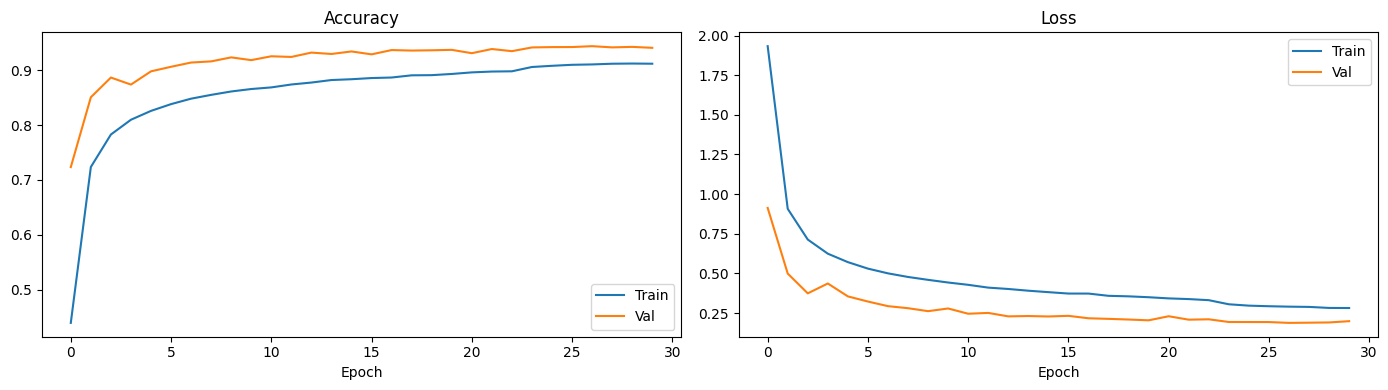

In [35]:
# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_title('Accuracy'); ax1.legend(); ax1.set_xlabel('Epoch')

ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('Loss'); ax2.legend(); ax2.set_xlabel('Epoch')

plt.tight_layout()
plt.show()

## 5. Baseline Evaluation (default threshold = 0.5)

In [36]:
# Get softmax probabilities on the test set
probs_test = model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)  # shape: (N, NUM_CLASSES)

def evaluate_with_threshold(probs, y_true, threshold, cost_fr=COST_FALSE_REJECT,
                            cost_fa=COST_FALSE_ACCEPT, label_names=None):
    """
    Evaluate predictions using a confidence threshold.
    
    A prediction is accepted only if max(probs) >= threshold.
    Rejected samples (max prob < threshold) are treated as 'unknown' — 
    they count as false rejects if the true label was a known command.
    
    Returns dict of metrics.
    """
    max_probs  = probs.max(axis=1)           # confidence of top prediction
    pred_class = probs.argmax(axis=1)        # predicted class index

    accepted = max_probs >= threshold
    rejected = ~accepted

    # Final predictions: accepted → predicted class, rejected → -1 (unknown)
    final_pred = np.where(accepted, pred_class, -1)

    # Accuracy (only on accepted samples)
    correct   = (final_pred == y_true) & accepted
    accuracy  = correct.sum() / len(y_true)

    # Macro-F1 (on accepted samples only)
    mask = accepted
    macro_f1 = f1_score(y_true[mask], pred_class[mask],
                        average='macro', zero_division=0) if mask.any() else 0.0

    # False reject rate: how many real commands were rejected
    false_rejects = rejected.sum()  # all rejections are false rejects (true label is a command)
    fr_rate = false_rejects / len(y_true)

    # False accept rate: accepted but wrong class
    false_accepts = ((final_pred != y_true) & accepted).sum()
    fa_rate = false_accepts / len(y_true)

    # Expected cost
    expected_cost = (false_rejects * cost_fr + false_accepts * cost_fa) / len(y_true)

    return {
        'threshold':     threshold,
        'accuracy':      accuracy,
        'macro_f1':      macro_f1,
        'fr_rate':       fr_rate,
        'fa_rate':       fa_rate,
        'expected_cost': expected_cost,
        'accept_rate':   accepted.mean()
    }


baseline = evaluate_with_threshold(probs_test, y_test, threshold=0.5)
print('── Baseline (threshold=0.5) ───────────────')
for k, v in baseline.items():
    print(f'  {k:<18}: {v:.4f}')

172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
── Baseline (threshold=0.5) ───────────────
  threshold         : 0.5000
  accuracy          : 0.9217
  macro_f1          : 0.9598
  fr_rate           : 0.0439
  fa_rate           : 0.0344
  expected_cost     : 0.1222
  accept_rate       : 0.9561


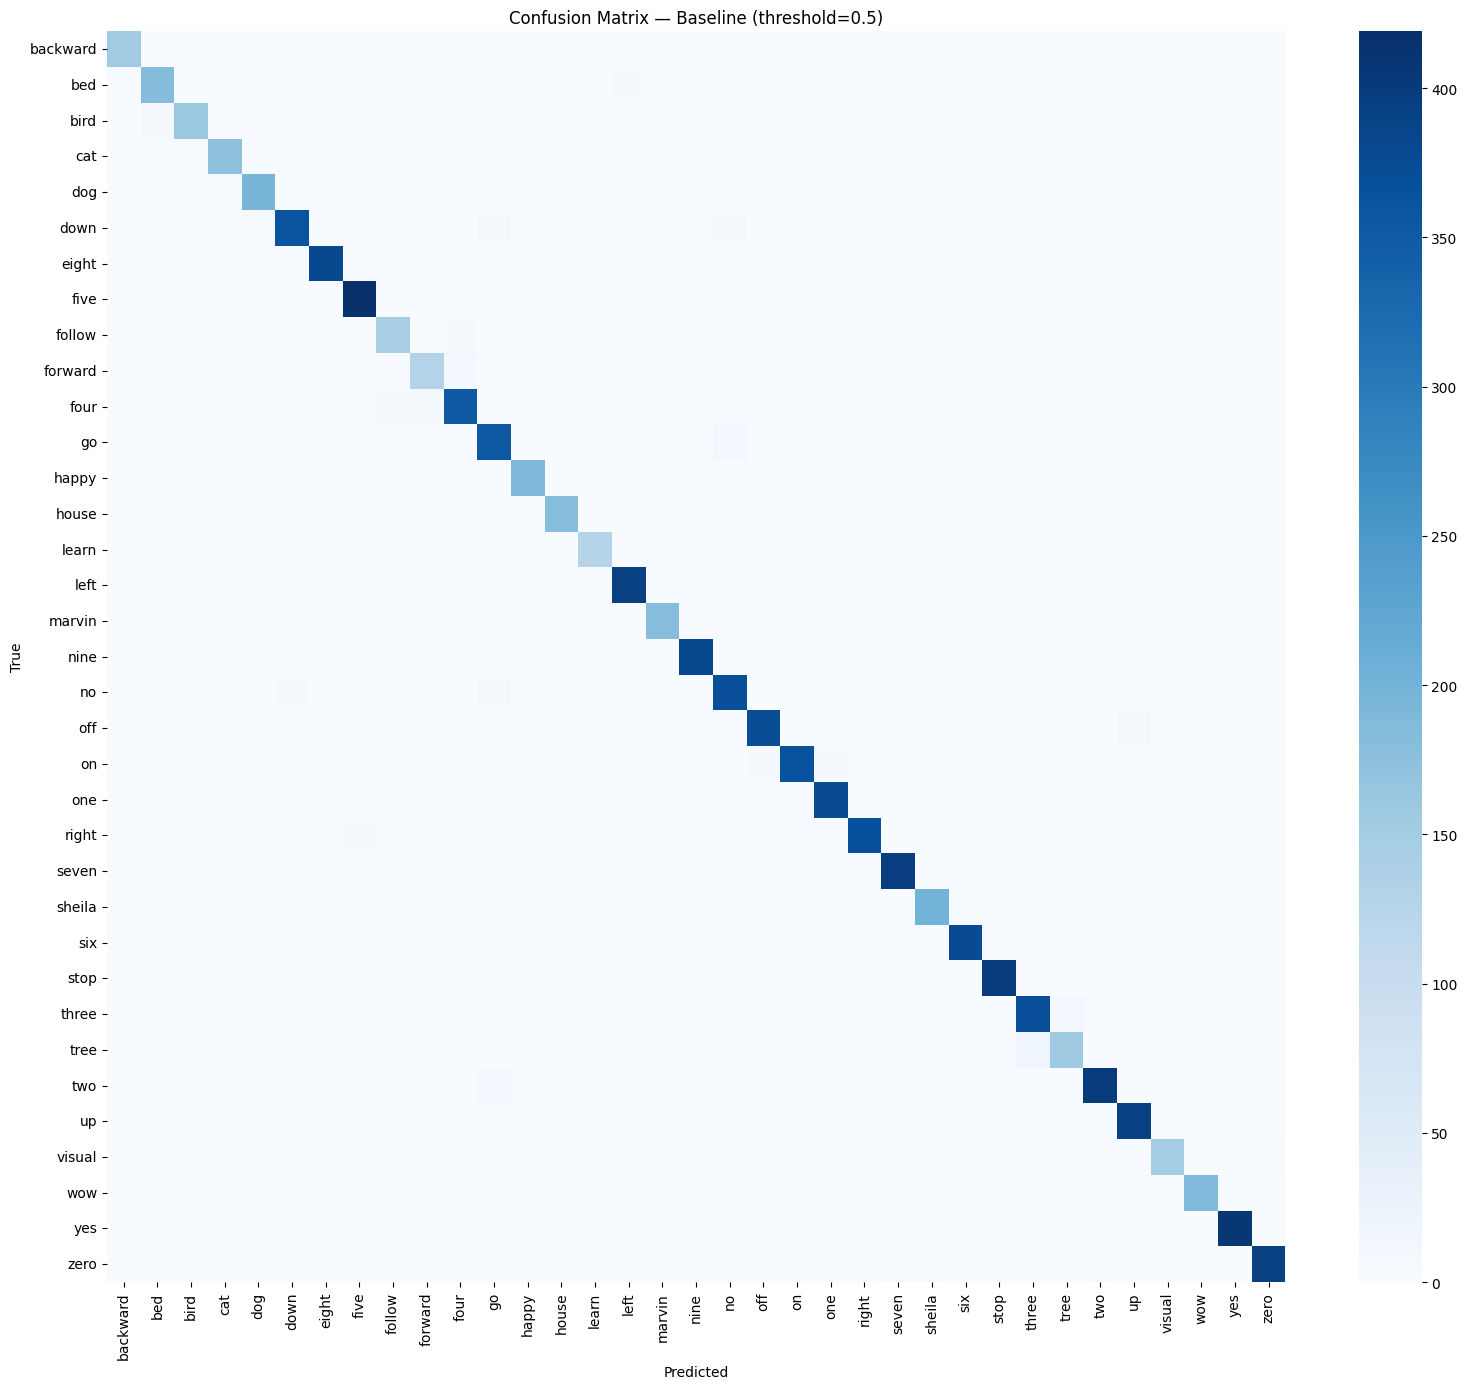

              precision    recall  f1-score   support

    backward       0.98      0.98      0.98       158
         bed       0.90      0.93      0.92       197
        bird       0.98      0.93      0.96       173
         cat       0.97      0.97      0.97       180
         dog       0.95      0.95      0.95       206
        down       0.95      0.94      0.95       385
       eight       0.98      0.98      0.98       389
        five       0.97      0.98      0.97       429
      follow       0.92      0.89      0.90       162
     forward       0.92      0.90      0.91       143
        four       0.94      0.96      0.95       368
          go       0.92      0.94      0.93       377
       happy       0.97      0.97      0.97       194
       house       0.99      0.97      0.98       186
       learn       0.89      0.89      0.89       143
        left       0.95      0.98      0.97       401
      marvin       1.00      0.97      0.99       186
        nine       0.97    

In [37]:
# Confusion matrix at baseline
pred_baseline = np.where(probs_test.max(axis=1) >= 0.5, probs_test.argmax(axis=1), -1)
mask = pred_baseline != -1

cm = confusion_matrix(y_test[mask], pred_baseline[mask])
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Baseline (threshold=0.5)')
plt.tight_layout()
plt.show()

print(classification_report(y_test[mask], pred_baseline[mask],
                             target_names=le.classes_, zero_division=0))

## 6. RL Threshold Tuning Agent

We model threshold selection as a **1-D continuous bandit / Q-learning problem**:
- **State**: discretized confidence threshold in [0, 1]
- **Action**: lower / keep / raise threshold
- **Reward**: negative expected cost (we want to minimise false rejects → lower cost)

The agent observes a mini-batch of validation predictions, computes the expected cost at the current threshold, and updates a Q-table.

In [38]:
class ThresholdRLAgent:
    """
    Tabular Q-learning agent that tunes a decision threshold
    to minimise expected cost under asymmetric error penalties.

    State  : discretized threshold index in {0, 1, ..., n_states-1}
    Actions: 0=lower, 1=keep, 2=raise  (step size = 1 / n_states)
    Reward : -expected_cost (negative because RL maximises reward)
    """

    def __init__(self, n_states=20, alpha=0.1, gamma=0.9,
                 epsilon=0.3, epsilon_decay=0.995, epsilon_min=0.01,
                 cost_fr=COST_FALSE_REJECT, cost_fa=COST_FALSE_ACCEPT):
        self.n_states    = n_states
        self.alpha       = alpha        # learning rate
        self.gamma       = gamma        # discount factor
        self.epsilon     = epsilon      # exploration rate
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.cost_fr     = cost_fr
        self.cost_fa     = cost_fa

        # Q-table: shape (n_states, 3)
        self.Q = np.zeros((n_states, 3))

        # Start at middle threshold
        self.state = n_states // 2

    @property
    def threshold(self):
        """Current threshold value in [0, 1]."""
        return self.state / self.n_states

    def _next_state(self, action):
        if action == 0:   # lower
            return max(0, self.state - 1)
        elif action == 2: # raise
            return min(self.n_states - 1, self.state + 1)
        return self.state # keep

    def _compute_reward(self, probs_batch, labels_batch):
        """Reward = negative expected cost on the current mini-batch."""
        metrics = evaluate_with_threshold(
            probs_batch, labels_batch, self.threshold,
            self.cost_fr, self.cost_fa
        )
        return -metrics['expected_cost']

    def select_action(self):
        """Epsilon-greedy action selection."""
        if np.random.rand() < self.epsilon:
            return np.random.randint(3)
        return np.argmax(self.Q[self.state])

    def step(self, probs_batch, labels_batch):
        """One RL step: select action → transition → observe reward → update Q."""
        action     = self.select_action()
        next_state = self._next_state(action)

        # Observe reward at NEW state
        old_state   = self.state
        self.state  = next_state
        reward      = self._compute_reward(probs_batch, labels_batch)

        # Q-update
        td_target = reward + self.gamma * np.max(self.Q[next_state])
        td_error  = td_target - self.Q[old_state, action]
        self.Q[old_state, action] += self.alpha * td_error

        # Decay exploration
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

        return reward, self.threshold


print('RL agent defined.')

RL agent defined.


In [39]:
# Use validation set to train the RL agent
probs_val = model.predict(X_val, batch_size=BATCH_SIZE, verbose=0)

agent = ThresholdRLAgent(n_states=20, alpha=0.1, gamma=0.9, epsilon=0.5)

EPISODES   = 300
BATCH_SIZE_RL = 256    # samples per episode

reward_history   = []
threshold_history = []

for ep in range(EPISODES):
    # Sample a mini-batch from validation
    idx = np.random.choice(len(probs_val), size=BATCH_SIZE_RL, replace=False)
    reward, thr = agent.step(probs_val[idx], y_val[idx])
    reward_history.append(reward)
    threshold_history.append(thr)

optimal_threshold = agent.threshold
print(f'RL-tuned threshold: {optimal_threshold:.3f}  (started at 0.500)')

RL-tuned threshold: 0.150  (started at 0.500)


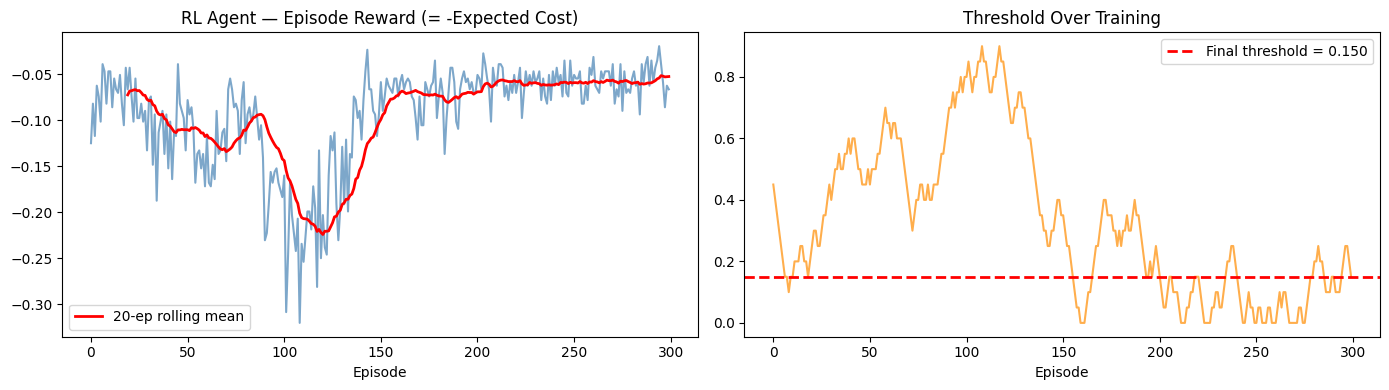

In [40]:
# Plot RL training progress
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(reward_history, alpha=0.7, color='steelblue')
ax1.plot(pd.Series(reward_history).rolling(20).mean(), color='red', lw=2, label='20-ep rolling mean')
ax1.set_title('RL Agent — Episode Reward (= -Expected Cost)')
ax1.set_xlabel('Episode'); ax1.legend()

ax2.plot(threshold_history, alpha=0.7, color='darkorange')
ax2.axhline(optimal_threshold, color='red', lw=2, linestyle='--',
            label=f'Final threshold = {optimal_threshold:.3f}')
ax2.set_title('Threshold Over Training')
ax2.set_xlabel('Episode'); ax2.legend()

plt.tight_layout()
plt.show()

## 7. Final Evaluation — Baseline vs RL-tuned Threshold

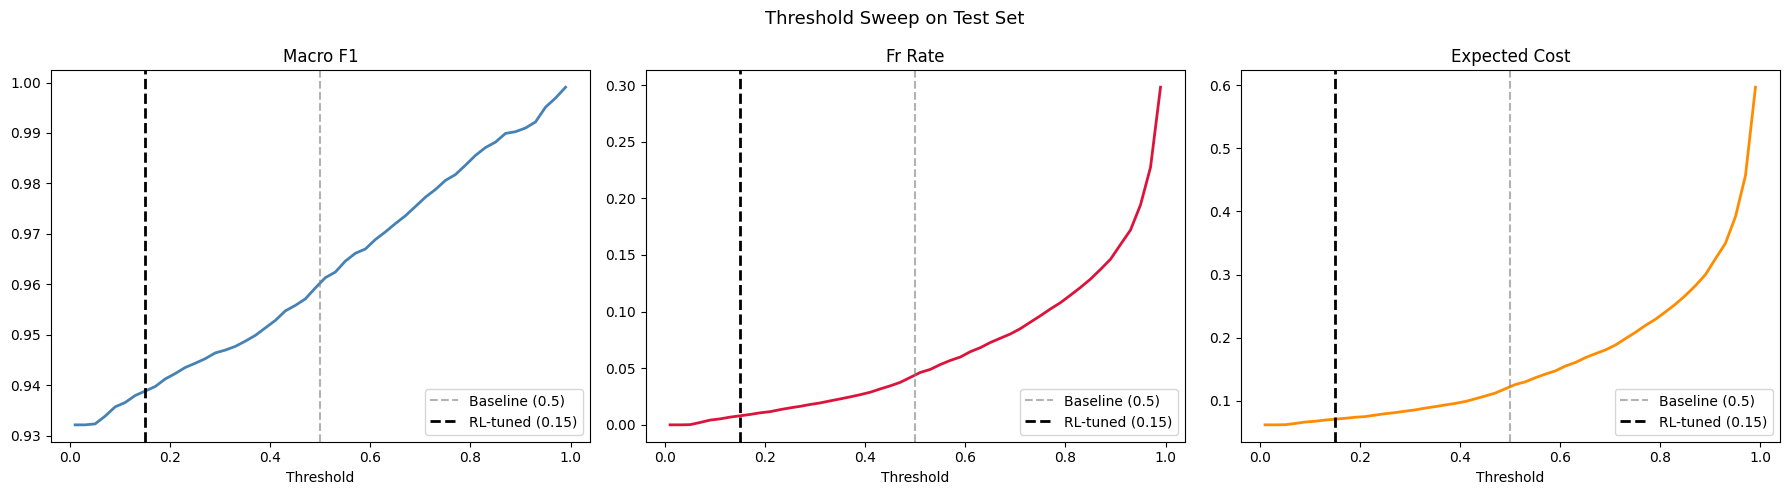

In [41]:
# Sweep thresholds to visualise the trade-off curve
thresholds = np.linspace(0.01, 0.99, 50)
results = [evaluate_with_threshold(probs_test, y_test, t) for t in thresholds]
results_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, color in zip(axes,
                              ['macro_f1', 'fr_rate', 'expected_cost'],
                              ['steelblue', 'crimson', 'darkorange']):
    ax.plot(results_df['threshold'], results_df[metric], color=color, lw=2)
    ax.axvline(0.5, color='gray', linestyle='--', alpha=0.6, label='Baseline (0.5)')
    ax.axvline(optimal_threshold, color='black', linestyle='--', lw=2,
               label=f'RL-tuned ({optimal_threshold:.2f})')
    ax.set_title(metric.replace('_', ' ').title())
    ax.set_xlabel('Threshold'); ax.legend()

plt.suptitle('Threshold Sweep on Test Set', fontsize=13)
plt.tight_layout()
plt.show()

In [42]:
# Side-by-side comparison
rl_result = evaluate_with_threshold(probs_test, y_test, optimal_threshold)

compare_df = pd.DataFrame([baseline, rl_result]).set_index('threshold').T
compare_df.columns = [f'Baseline (thr=0.50)', f'RL-tuned (thr={optimal_threshold:.2f})']
print('\n── Test Set Results ──────────────────────────────────────────')
print(compare_df.to_string(float_format=lambda x: f'{x:.4f}'))


── Test Set Results ──────────────────────────────────────────
               Baseline (thr=0.50)  RL-tuned (thr=0.15)
accuracy                    0.9217               0.9373
macro_f1                    0.9598               0.9389
fr_rate                     0.0439               0.0080
fa_rate                     0.0344               0.0547
expected_cost               0.1222               0.0707
accept_rate                 0.9561               0.9920


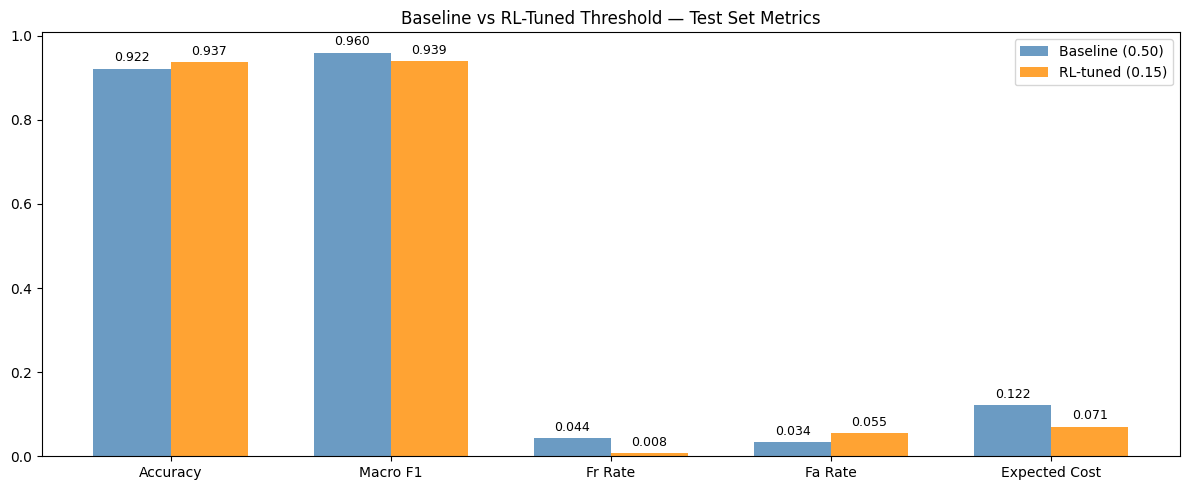

In [43]:
# Bar chart comparison
metrics_to_plot = ['accuracy', 'macro_f1', 'fr_rate', 'fa_rate', 'expected_cost']
x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, [baseline[m]    for m in metrics_to_plot], width,
               label='Baseline (0.50)', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, [rl_result[m] for m in metrics_to_plot], width,
               label=f'RL-tuned ({optimal_threshold:.2f})', color='darkorange', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels([m.replace('_', ' ').title() for m in metrics_to_plot])
ax.set_title('Baseline vs RL-Tuned Threshold — Test Set Metrics')
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

## 8. Ethics Audit — Per-Speaker Fairness

The Google Speech Commands V2 dataset includes speaker IDs. We check whether accuracy / false-reject rate is consistent across speakers to surface potential accent/dialect bias.

In [44]:
# Build a test dataframe with predictions
df_test = df[df['split']=='test'].copy().reset_index(drop=True)

# Extract speaker ID from filename (format: speakerid_nonce.wav)
df_test['speaker'] = df_test['path'].apply(
    lambda p: os.path.basename(p).split('_')[0]
)

# Attach predictions
df_test['pred_class']  = probs_test.argmax(axis=1)
df_test['confidence']  = probs_test.max(axis=1)
df_test['accepted']    = df_test['confidence'] >= optimal_threshold
df_test['correct']     = df_test['pred_class'] == df_test['label_id']
df_test['false_reject'] = ~df_test['accepted']

# Per-speaker summary (speakers with >= 10 test samples)
speaker_stats = df_test.groupby('speaker').agg(
    n_samples    = ('label_id', 'count'),
    accuracy     = ('correct',  'mean'),
    fr_rate      = ('false_reject', 'mean')
).query('n_samples >= 10').sort_values('fr_rate', ascending=False)

print(f'Speakers with >=10 test samples: {len(speaker_stats)}')
print(speaker_stats.head(10).to_string())

Speakers with >=10 test samples: 224
          n_samples  accuracy   fr_rate
speaker                                
8ea6dec6         32  0.125000  0.906250
3659fc1c         34  0.382353  0.323529
475b61f1         23  0.260870  0.304348
a9f54d8d         14  0.357143  0.285714
dfdabe19         28  0.607143  0.214286
220ee1ef         17  0.294118  0.176471
82d0d3ba         18  0.611111  0.166667
c9e251d2         30  0.500000  0.166667
2005ca25         27  0.481481  0.111111
f17d21b5         11  0.727273  0.090909


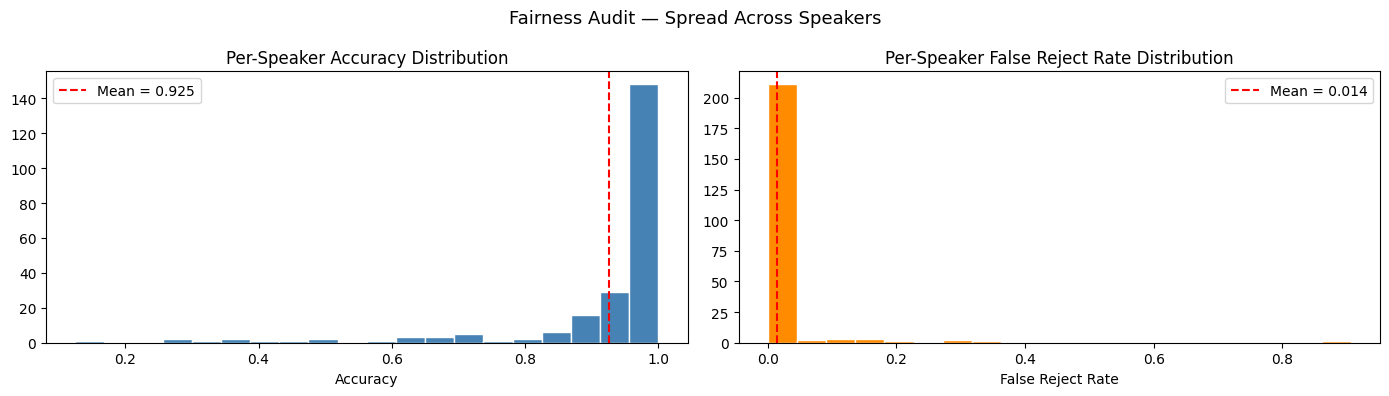


Accuracy std across speakers:     0.1494
False reject rate std across speakers: 0.0744

Note: high std indicates potential accent/dialect fairness concerns.


In [45]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.hist(speaker_stats['accuracy'], bins=20, color='steelblue', edgecolor='white')
ax1.axvline(speaker_stats['accuracy'].mean(), color='red', linestyle='--',
            label=f'Mean = {speaker_stats["accuracy"].mean():.3f}')
ax1.set_title('Per-Speaker Accuracy Distribution')
ax1.set_xlabel('Accuracy'); ax1.legend()

ax2.hist(speaker_stats['fr_rate'], bins=20, color='darkorange', edgecolor='white')
ax2.axvline(speaker_stats['fr_rate'].mean(), color='red', linestyle='--',
            label=f'Mean = {speaker_stats["fr_rate"].mean():.3f}')
ax2.set_title('Per-Speaker False Reject Rate Distribution')
ax2.set_xlabel('False Reject Rate'); ax2.legend()

plt.suptitle('Fairness Audit — Spread Across Speakers', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\nAccuracy std across speakers:     {speaker_stats["accuracy"].std():.4f}')
print(f'False reject rate std across speakers: {speaker_stats["fr_rate"].std():.4f}')
print('\nNote: high std indicates potential accent/dialect fairness concerns.')

## 9. Summary

| Component | Details |
|---|---|
| **Feature** | Log-Mel Spectrogram (64 mel bins, 1024-pt FFT) |
| **Model** | 4-block Conv2D + GlobalAvgPool + Dense |
| **RL Agent** | Tabular Q-learning, 20 threshold states, ε-greedy |
| **Cost** | FR penalty=2.0, FA penalty=1.0 (false-reject minimisation) |
| **Metrics** | Accuracy, Macro-F1, Expected Cost, FR rate, FA rate |
| **Ethics** | Per-speaker accuracy and FR-rate fairness audit |

### Next Steps (Stretch Goals)
- **Noise robustness**: augment training with `librosa` noise injection / SpecAugment
- **On-device inference**: convert model to TFLite with `tf.lite.TFLiteConverter`
- **Deeper RL**: replace tabular Q-learning with a small DQN over a continuous threshold space